# **Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **Load the data**

In [ ]:
# loading testing data

# Make sure make changes to your relative file path in yout Google Drive

text_file_path = '/content/drive/My Drive/NLP/NLP_CW/data/test_text.txt'
label_file_path = '/content/drive/My Drive/NLP/NLP_CW/data/test_label.txt'

# Load the text data
with open(text_file_path, 'r', encoding='utf-8') as text_file:
    test_text = [line.strip().split(',') for line in text_file]

# Load the labels
with open(label_file_path, 'r', encoding='utf-8') as label_file:
    test_label = [int(line.strip()) for line in label_file]

print(test_text[0:300])
print(test_label[0:300])

[['ally', 'ally', 'financial', 'pull', 'outlook'], ['dell', 'hpe', 'dell', 'hpe', 'target', 'trimmed', 'compute', 'headwind'], ['prty', 'moody', 'turn', 'negative', 'party', 'city'], ['san', 'deutsche', 'bank', 'cut', 'hold'], ['sitc', 'compass', 'point', 'cut', 'sell'], ['tap', 'barclays', 'cool', 'molson', 'coors'], ['tap', 'barclays', 'cut', 'equal', 'weight'], ['analyst', 'eviscerate', 'musk', 'cybertruck', 'response', 'felt', 'success'], ['barclays', 'assigns', 'chance', 'study', 'gilead', 'antiviral', 'drug', 'done', 'china', 'succeed'], ['btig', 'point', 'breakfast', 'pressure', 'dunkin', 'brand'], ['child', 'place', 'downgraded', 'neutral', 'outperform', 'wedbush', 'price', 'target', 'slashed'], ['clovis', 'oncology', 'downgraded', 'line', 'outperform', 'evercore', 'isi'], ['downgrade', 'aan', 'bdn', 'becn', 'bte', 'cdev', 'chk', 'coop', 'cpe', 'cva', 'dan', 'doc', 'drh', 'epr', 'esrt', 'etm', 'fast', 'fbm', 'gm', 'gm'], ['goldman', 'pull', 'progressive', 'goldman', 'conviction

In [ ]:
#Converting y_test labels to array

from sklearn.preprocessing import LabelEncoder
import numpy as np

encoder = LabelEncoder()
encoder.fit(y_test)

y_test = test_label
y_test = encoder.transform(y_test)
y_test = np.array(y_test)

# **Load the model**

In [ ]:
from joblib import load

# path to the saved model file
filepath = '/content/drive/MyDrive/NLP/NLP_CW/model/dt_ngram_clf.joblib'

# Load the model
dt_ngram_clf = load(filepath)

# Verify the loaded model by printing
print(dt_ngram_clf)


DecisionTreeClassifier(max_depth=30, min_samples_split=5, random_state=42)


# **N-gram with range of (1, 3)**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# text data variables and their labels
X_test = test_text

# label variables are imported from previous section which remains array
y_test = y_test

In [ ]:
#  Convert Tokenized Text Back to Strings
X_test = [' '.join(doc) for doc in test_text]

# apply CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer with Specific N-gram Range
# This parameter tells the vectorizer to consider unigrams (single words),
# bigrams (two consecutive words), and trigrams (three consecutive words)
vectorizer = CountVectorizer(ngram_range=(1, 3))
vectorizer.fit(X_test)
X_test = vectorizer.transform(X_test)


# **N-gram + DT**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# fit the model with test data
dt_ngram_clf.fit(X_test, y_test)

# Predict the response for the test dataset
y_pred = dt_ngram_clf.predict(X_test)

# Evaluating the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8492462311557789
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.50      0.66       347
           1       0.97      0.64      0.77       475
           2       0.82      0.99      0.90      1566

    accuracy                           0.85      2388
   macro avg       0.91      0.71      0.77      2388
weighted avg       0.87      0.85      0.84      2388



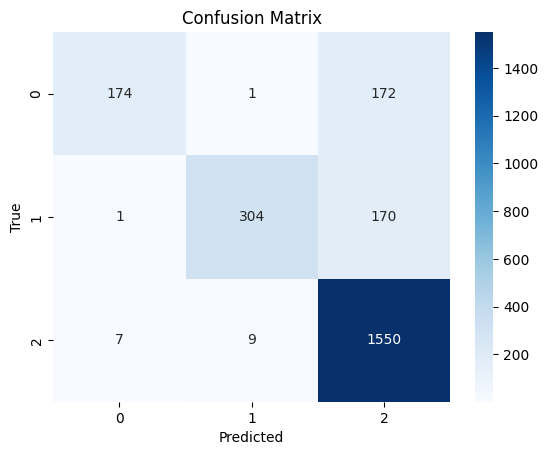

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


# **BERT**

# **Load and Prepare the Data**

In [ ]:
pip install transformers datasets torch


In [ ]:
from datasets import load_dataset

# Load dataset
dataset = load_dataset('zeroshot/twitter-financial-news-sentiment')
test_set = dataset['validation']

# Prepare the data
X_test = test_set['text']
y_test = test_set['label']

# **Pre-process Data for BERT**

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# # Load BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

def encode_data(tokenizer, texts, max_length=512):
    return tokenizer(texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt")

# Tokenize data
# train_encodings = encode_data(tokenizer, X_train)
test_encodings = encode_data(tokenizer, X_test)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


# **Convert Labels and Encodings to PyTorch Datasets**

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch

# Convert to tensor
test_labels = torch.tensor(y_test)

# dataset
test_dataset = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], test_labels)

# Slicing the datasets to take only 1/4 of the data
quarter_test_size = len(test_dataset) // 4

# sliced datasets
test_dataset_quarter = TensorDataset(test_dataset.tensors[0][:quarter_test_size],
                                     test_dataset.tensors[1][:quarter_test_size],
                                     test_dataset.tensors[2][:quarter_test_size])

# data loader with the sliced datasets
test_loader = DataLoader(test_dataset_quarter, batch_size=8, sampler=SequentialSampler(test_dataset_quarter))


# **Load the model**

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizer, AdamW, get_scheduler
import torch
import os

# Mount Google Drive (already done)
from google.colab import drive
drive.mount('/content/drive')

# Base directory where the model is saved
base_dir = '/content/drive/My Drive/NLP/NLP_CW/model/'

# Paths to saved model, optimizer, and scheduler states
model_path = os.path.join(base_dir, 'bert_model.bin')
optimizer_path = os.path.join(base_dir, 'optimizer_state.bin')
scheduler_path = os.path.join(base_dir, 'scheduler_state.bin')

# Initialize the same model architecture
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)  # Adjust num_labels as needed

# Load the state dictionary into the model
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# Initialize the optimizer (using the same settings as during training)
optimizer = AdamW(model.parameters(), lr=2e-5)

# Load the optimizer state
optimizer.load_state_dict(torch.load(optimizer_path, map_location=torch.device('cpu')))

# Initialize the learning rate scheduler
num_training_steps = 1000  # Example; replace with your original number of training steps
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)

# Load the scheduler state
lr_scheduler.load_state_dict(torch.load(scheduler_path, map_location=torch.device('cpu')))

print("Model, optimizer, and scheduler loaded successfully.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:521: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Model, optimizer, and scheduler loaded successfully.


# **Evaluate the Model**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Switch model to evaluation mode
model.eval()
predictions, true_labels = [], []

# Predict
for batch in test_loader:
    b_input_ids, b_input_mask, b_labels = batch
    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
    logits = outputs.logits
    predictions.append(logits.argmax(dim=-1).cpu().numpy())
    true_labels.append(b_labels.cpu().numpy())

# Calculate the accuracy
predictions = np.concatenate(predictions)
true_labels = np.concatenate(true_labels)
print("Test Accuracy:", accuracy_score(true_labels, predictions))
print("Classification Report:\n", classification_report(true_labels, predictions))


Test Accuracy: 0.8760469011725294
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.78      0.73        72
           1       0.85      0.76      0.80       103
           2       0.92      0.92      0.92       422

    accuracy                           0.88       597
   macro avg       0.82      0.82      0.82       597
weighted avg       0.88      0.88      0.88       597



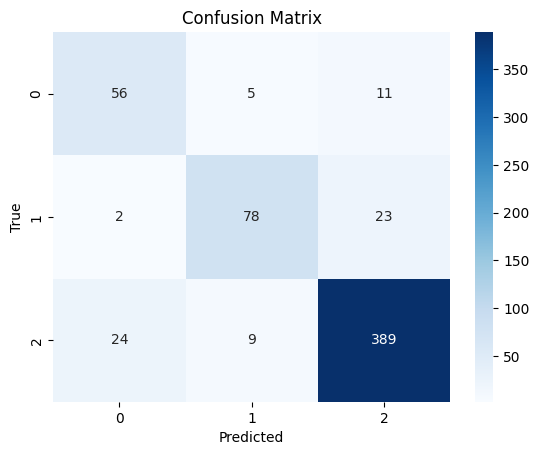

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate and plot the confusion matrix
cm = confusion_matrix(true_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
